In [19]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatwCDM
import camb
import sys
import os
import time

# Add the source directory to the Python path to use local development version
sys.path.insert(0, os.path.abspath('/datadec/cppm/boccard/excursion_set_functions/src'))

# Import from reference repository
from excursion_set_functions import analytical as f_an_py
from excursion_set_functions import integration
from excursion_set_functions import numerical
from excursion_set_functions import analytical
from excursion_set_functions.python import numerical as num_py
from excursion_set_functions.python import integration as int_py
from excursion_set_functions.utilities import delta_NL_underdensity


# Import photo-z module from local development source
from excursion_set_functions.python.photo_z import compute_vsf_eulerian_with_photoz

import scipy.special as sp
from matplotlib import ticker

# Enable LaTeX for text rendering with better compatibility
plt.rcParams['text.usetex'] = True
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14

COMPUTING REFERENCE VSF (original implementation)
COMPUTING REFERENCE VSF (from original code)
COMPUTING REFERENCE VSF (from original code)

COMPUTING PHOTO-Z VSF

--------------------------------------------------------------------------------
Isotropic case (sigma_z = 0)
--------------------------------------------------------------------------------
Computing power spectrum with CAMB...

COMPUTING PHOTO-Z VSF

--------------------------------------------------------------------------------
Isotropic case (sigma_z = 0)
--------------------------------------------------------------------------------
Computing power spectrum with CAMB...
Using R range: 100.0 → 1.0 Mpc/h (Lagrangian)

Photo-z parameter: sigma_chi = 0.00 Mpc/h

Computing variances and W parameter...
Computing S, dS/dR, and W for 101 radii using reference method...
  Progress: 20/101 radii computed
  Progress: 40/101 radii computed
  Progress: 60/101 radii computed
  Progress: 80/101 radii computed
  Progress: 100/101 rad

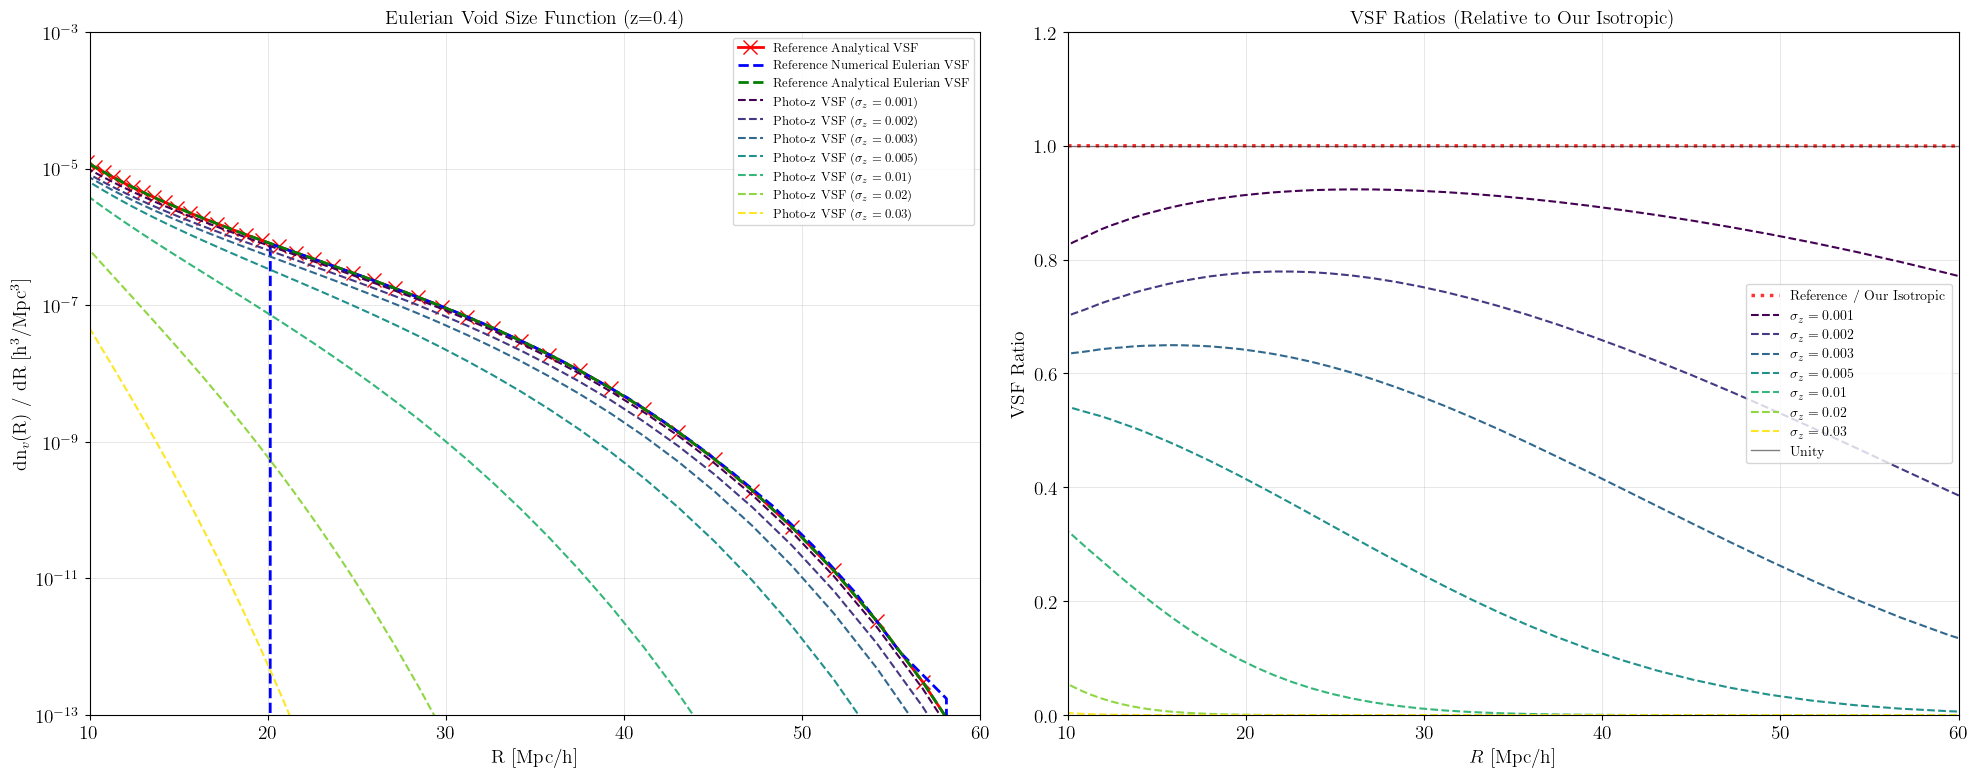


COMPUTATION COMPLETE


In [27]:
def plot_vsf_comparison():
    """
    Generate comparison plot of VSF with and without photo-z effects.
    """
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    ax = axes[0]
    
    # ===== COSMOLOGY AND POWER SPECTRUM =====
    omega_m = 0.3
    w = -1.0
    redshift_min, redshift_max = 0.3, 0.5
    cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
    z_mean = (redshift_min + redshift_max) / 2.0
    
    print("="*80)
    print("COMPUTING REFERENCE VSF (original implementation)")
    print("="*80)
    
    # Compute power spectrum
    pars = camb.CAMBparams()
    pars.set_cosmology(
        H0=cosmo.H0.value, 
        ombh2=cosmo.Ob0 * (cosmo.H0.value / 100)**2, 
        omch2=(cosmo.Om0 - cosmo.Ob0) * (cosmo.H0.value / 100)**2
    )
    pars.InitPower.set_params(ns=0.965)
    redshift = np.linspace(redshift_min, redshift_max, 10)[::-1]
    pars.set_matter_power(redshifts=redshift, kmax=2.0)
    results = camb.get_results(pars)
    k, z_arr, pk = results.get_matter_power_spectrum(minkh=1.e-4, maxkh=2, npoints=1000)
    Pk = np.mean(pk.T, axis=1)
    
    # Reference computation
    R = np.logspace(2, 0, 101)
    s = integration.sigma2_TopHat(Pk, k, R)
    s22 = integration.sigma2_2_TopHat_numdiff(Pk, k, R)
    dsdR = integration.dSdR_TopHat(Pk, k, R)
    DW = s22 / dsdR**2
    
    delta_v_lin = -0.8
    alpha = 0.517 * abs(delta_v_lin) - 0.089
    beta = 0.098 * abs(delta_v_lin) + 0.103
    gamma = 1
    
    B = alpha * (1.0 + (beta / s**0.5)**gamma)
    dB_ds = -0.5 * alpha * beta**gamma * gamma * s**(-gamma/2.0 - 1.0)
    
    f_appr_R = f_an_py.f_S_MB_approx(s, DW, B, dB_ds) * np.abs(dsdR)
    VSF_approx_L = 3.0 / (4.0 * np.pi * R**3) * f_appr_R
    
    delta_v_NL = delta_NL_underdensity(delta_v_lin)
    expansion_factor = (1.0 + delta_v_NL)**(-1.0/3.0)
    R_E = R * expansion_factor
    VSF_approx_E = VSF_approx_L / expansion_factor
    
    ax.plot(R_E, VSF_approx_E, label='Reference Analytical VSF', 
            color='red', marker='x', markersize=10, linewidth=2)
    
    
    
    
    
    
    # ===== REFERENCE CODE COMPUTATION =====
    omega_m = 0.3
    w = -1.0
    cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
    z_mean = (redshift_min + redshift_max) / 2.0
    
    print("="*80)
    print("COMPUTING REFERENCE VSF (from original code)")
    print("="*80)
    
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=cosmo.H0.value, 
                        ombh2=cosmo. Ob0 * (cosmo.H0.value / 100)**2, 
                        omch2=(cosmo.Om0-cosmo.Ob0) * (cosmo.H0.value / 100)**2)
    pars.InitPower. set_params(ns=0.965)
    redshift = np.linspace(redshift_min, redshift_max, 10)[::-1]
    pars.set_matter_power(redshifts=redshift, kmax=2.0)
    results = camb.get_results(pars)
    k, z_arr, pk = results. get_matter_power_spectrum(minkh=1.e-4, maxkh=2, npoints=1000)
    Pk = np.mean(pk.T, axis=1)
    R = np.logspace(2,0,101) #R must be decreasing for numerical excursion-set functions
    Cij = integration.C_ij_TopHat(Pk,k,R)
    Cij_cpp = integration.C_ij_TopHat(Pk,k,R)
    s = integration.sigma2_TopHat(Pk,k,R)
    s_cpp = integration.sigma2_TopHat(Pk,k,R)
    s22 = integration.sigma2_2_TopHat_numdiff(Pk,k,R)
    s22_cpp = integration.sigma2_2_TopHat_numdiff(Pk,k,R)
    dsdR = integration.dSdR_TopHat(Pk,k,R)
    dsdR_cpp = integration.dSdR_TopHat(Pk,k,R)
    DW = s22 / dsdR ** 2
    DW_cpp = s22_cpp / dsdR_cpp ** 2
    Npaths = int(1e7) # number of random-walk realization
    delta_v_lin = -0.8
    alpha = 0.517*abs(delta_v_lin) - 0.089
    beta = 0.098*abs(delta_v_lin) + 0.103
    params_B = [alpha,beta,gamma]
    B = params_B[0] * (1. + (params_B[1]/s**0.5)**params_B[2])
    dB_ds = -0.5*params_B[0]*params_B[1]**params_B[2]*params_B[2] * s **(-params_B[2]/2.-1)
    Lij = int_py.cholensky_decomposition_matrix_from_Cij(Cij)
    Ncross = num_py.first_crossing_single_barrier(Lij, 100, B)
    t0 = time.time()
    Ncross = num_py.first_crossing_single_barrier(Lij, Npaths, B)
    dt = time.time() - t0
    t0 = time.time()
    Ncross_cpp = numerical.first_crossing_single_barrier(Lij, Npaths, B)
    dt = time.time() - t0
    dR = R[:-1] - R[1:]
    Rmean = 0.5 * (R[:-1] + R[1:])
    f_num_R = Ncross[1:] / Npaths / dR
    f_num_R_cpp = Ncross_cpp[1:] / Npaths / dR
    f_appr_R = f_an_py.f_S_MB_approx(s,DW,B,dB_ds) * np.abs(dsdR)
    f_appr_R_cpp = analytical.f_S_MB_approx(s,DW,B,dB_ds) * np.abs(dsdR)
    VSF_num_L = 3. / (4. * np.pi * Rmean**3) * f_num_R
    VSF_approx_L = 3. / (4. * np.pi * R**3) * f_appr_R
    delta_v_NL = delta_NL_underdensity(delta_v_lin)
    expansion_factor = (1.+delta_v_NL)**(-1./3.)
    Rmean_E = Rmean * expansion_factor
    R_E = R * expansion_factor
    VSF_num_E = (3. / (4. * np.pi * Rmean **3) * f_num_R) / expansion_factor
    VSF_approx_E = (3. / (4. * np.pi * R **3) * f_appr_R) / expansion_factor
        
    ax.plot(Rmean_E, VSF_num_E, label='Reference Numerical Eulerian VSF', color='blue', linestyle='--', linewidth=2)
    ax.plot(R_E, VSF_approx_E, label='Reference Analytical Eulerian VSF', color='green', linestyle='--', linewidth=2)
    # ax.plot(Rmean, VSF_num_L, label='Reference Numerical Lagrangian VSF', color='orange', linestyle='--', linewidth=2)
    # ax.plot(R, VSF_approx_L, label='Reference Analytical Lagrangian VSF', color='purple', linestyle='--', linewidth=2)
    
    
    
    
    
    
    
    # ===== OUR IMPLEMENTATION =====
    print("\n" + "="*80)
    print("COMPUTING PHOTO-Z VSF")
    print("="*80)
    
    # Parameters
    a1, a2 = 0.517, -0.089
    b1, b2 = 0.098, 0.103
    bias = 2
    
    power_spectrum_cache = {}
    
    # Isotropic case
    print("\n" + "-"*80)
    print("Isotropic case (sigma_z = 0)")
    print("-"*80)
    
    R_E_iso, VSF_iso, s_iso = compute_vsf_eulerian_with_photoz(
        a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
        None, redshift_min, redshift_max, sigma_z=0.0,
        f_S_MB_approx_func=f_an_py.f_S_MB_approx,
        delta_NL_func=delta_NL_underdensity,
        power_spectrum_cache=power_spectrum_cache,
        verbose=True
    )
    
    # ax.plot(R_E_iso, VSF_iso, label=r'Our Isotropic VSF ($\sigma_z=0$)', 
    #         color='black', linewidth=1)
    
    # Photo-z cases
    sigma_array = [0.001, 0.002, 0.003, 0.005, 0.01, 0.02, 0.03]
    colors = plt.cm.viridis(np.linspace(0, 1, len(sigma_array)))
    
    for idx, sigma_z in enumerate(sigma_array):
        print(f"\n{'-'*80}")
        print(f"Photo-z case (sigma_z = {sigma_z})")
        print(f"{'-'*80}")
        
        R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
            a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
            None, redshift_min, redshift_max, sigma_z=sigma_z,
            f_S_MB_approx_func=f_an_py.f_S_MB_approx,
            delta_NL_func=delta_NL_underdensity,
            power_spectrum_cache=power_spectrum_cache,
            verbose=True
        )
        
        label = fr'Photo-z VSF ($\sigma_z = {sigma_z}$)'
        ax.plot(R_E_ph, VSF_ph, label=label, linestyle='--', color=colors[idx])
    
    # Format left plot
    ax.set_yscale('log')
    ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
    ax.set_ylabel(r'dn$_v$(R) / dR [h$^3$/Mpc$^3$]', fontsize=14)
    ax.set_xlim(10, 60)
    ax.set_ylim(1e-13, 1e-3)
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='-', linewidth=0.7, alpha=0.3)
    ax.legend(fontsize=9, loc='best')
    ax.set_title(f'Eulerian Void Size Function (z={z_mean:.1f})', fontsize=14)
    
    # ===== RATIO PLOT =====
    ax = axes[1]
    
    # Add reference/isotropic comparison
    print("\n" + "="*80)
    print("COMPUTING REFERENCE/ISOTROPIC RATIO")
    print("="*80)
    
    # Interpolate to common R grid for fair comparison
    from scipy.interpolate import interp1d
    
    # Find common R range
    R_common = np. linspace(
        max(R_E. min(), R_E_iso.min()),
        min(R_E.max(), R_E_iso.max()),
        200
    )
    
    # Interpolate both VSFs to common grid
    VSF_ref_interp = interp1d(R_E, VSF_approx_E, kind='cubic', 
                               bounds_error=False, fill_value=np.nan)
    VSF_iso_interp = interp1d(R_E_iso, VSF_iso, kind='cubic',
                               bounds_error=False, fill_value=np.nan)
    
    VSF_ref_common = VSF_ref_interp(R_common)
    VSF_iso_common = VSF_iso_interp(R_common)
    
    # Compute ratio
    valid_ref = ~np.isnan(VSF_ref_common) & ~np.isnan(VSF_iso_common) & (VSF_iso_common > 0)
    ratio_ref = np.full_like(R_common, np.nan)
    ratio_ref[valid_ref] = VSF_ref_common[valid_ref] / VSF_iso_common[valid_ref]
    
    # Plot reference/isotropic ratio
    ax.plot(R_common, ratio_ref, 
            label=r'Reference / Our Isotropic', 
            color='red', linestyle=':', linewidth=2.5, alpha=0.8)
    
    # Plot photo-z ratios
    for idx, sigma_z in enumerate(sigma_array):
        R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
            a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
            None, redshift_min, redshift_max, sigma_z=sigma_z,
            f_S_MB_approx_func=f_an_py.f_S_MB_approx,
            delta_NL_func=delta_NL_underdensity,
            power_spectrum_cache=power_spectrum_cache,
            verbose=False
        )
        
        valid = ~np.isnan(VSF_ph) & ~np.isnan(VSF_iso)
        if np.any(valid):
            ratio = np.full_like(VSF_ph, np.nan)
            ratio[valid] = VSF_ph[valid] / VSF_iso[valid]
            ax.plot(R_E_ph, ratio, label=fr'$\sigma_z={sigma_z}$', 
                   linestyle='--', color=colors[idx])
    
    ax.set_xlabel(r'$R$ [Mpc/h]', fontsize=14)
    ax.set_ylabel(r'VSF Ratio', fontsize=14)
    ax.axhline(1.0, color='black', linestyle='-', linewidth=1.0, alpha=0.5, label='Unity')
    ax.set_xlim(10, 60)
    ax.set_ylim(0.0, 1.2)
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='-', linewidth=0.7, alpha=0.3)
    ax.legend(fontsize=10, loc='best')
    ax.set_title(r'VSF Ratios (Relative to Our Isotropic)', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("COMPUTATION COMPLETE")
    print("="*80)


if __name__ == "__main__":
    plot_vsf_comparison()

COMPUTING REFERENCE VSF (original implementation)
COMPUTING REFERENCE VSF (from original code)
COMPUTING REFERENCE VSF (from original code)


/datadec/cppm/boccard/excursion_set_functions/src/excursion_set_functions/python/integration.py:79: RuntimeWarning: invalid value encountered in scalar power
  L_ij[j][j] = (Cij[j,j] - np.sum(L_ij[j][:j] ** 2)) ** 0.5


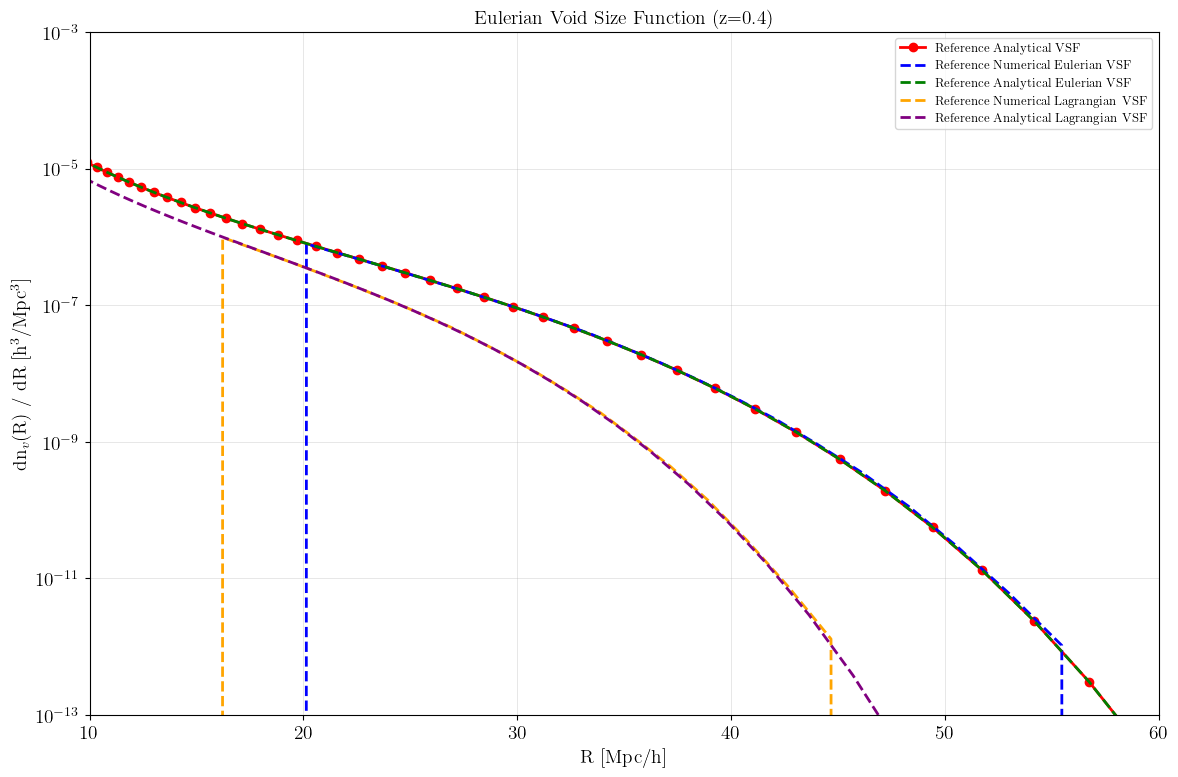

In [25]:
def plot_vsf_comparison():
    """
    Generate comparison plot of VSF with and without photo-z effects.
    """
    
    plt.figure(figsize=(12, 8))
    
    # ===== COSMOLOGY AND POWER SPECTRUM =====
    omega_m = 0.3
    w = -1.0
    redshift_min, redshift_max = 0.3, 0.5
    cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
    z_mean = (redshift_min + redshift_max) / 2.0
    
    print("="*80)
    print("COMPUTING REFERENCE VSF (original implementation)")
    print("="*80)
    
    # Compute power spectrum
    pars = camb.CAMBparams()
    pars.set_cosmology(
        H0=cosmo.H0.value, 
        ombh2=cosmo.Ob0 * (cosmo.H0.value / 100)**2, 
        omch2=(cosmo.Om0 - cosmo.Ob0) * (cosmo.H0.value / 100)**2
    )
    pars.InitPower.set_params(ns=0.965)
    redshift = np.linspace(redshift_min, redshift_max, 10)[::-1]
    pars.set_matter_power(redshifts=redshift, kmax=2.0)
    results = camb.get_results(pars)
    k, z_arr, pk = results.get_matter_power_spectrum(minkh=1.e-4, maxkh=2, npoints=1000)
    Pk = np.mean(pk.T, axis=1)
    
    R = np.logspace(2, 0, 101)
    s = integration.sigma2_TopHat(Pk, k, R)
    s22 = integration.sigma2_2_TopHat_numdiff(Pk, k, R)
    dsdR = integration.dSdR_TopHat(Pk, k, R)
    DW = s22 / dsdR**2
    
    delta_v_lin = -0.8
    alpha = 0.517 * abs(delta_v_lin) - 0.089
    beta = 0.098 * abs(delta_v_lin) + 0.103
    gamma = 1
    
    B = alpha * (1.0 + (beta / s**0.5)**gamma)
    dB_ds = -0.5 * alpha * beta**gamma * gamma * s**(-gamma/2.0 - 1.0)
    
    f_appr_R = f_an_py.f_S_MB_approx(s, DW, B, dB_ds) * np.abs(dsdR)
    VSF_approx_L = 3.0 / (4.0 * np.pi * R**3) * f_appr_R
    
    delta_v_NL = delta_NL_underdensity(delta_v_lin)
    expansion_factor = (1.0 + delta_v_NL)**(-1.0/3.0)
    R_E = R * expansion_factor
    VSF_approx_E = VSF_approx_L / expansion_factor
    
    plt.plot(R_E, VSF_approx_E, label='Reference Analytical VSF', 
            color='red', marker='o', linewidth=2)
    
    
    # ===== REFERENCE CODE COMPUTATION =====
    omega_m = 0.3
    w = -1.0
    cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
    z_mean = (redshift_min + redshift_max) / 2.0
    
    print("="*80)
    print("COMPUTING REFERENCE VSF (from original code)")
    print("="*80)
    
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=cosmo.H0.value, 
                        ombh2=cosmo. Ob0 * (cosmo.H0.value / 100)**2, 
                        omch2=(cosmo.Om0-cosmo.Ob0) * (cosmo.H0.value / 100)**2)
    pars.InitPower. set_params(ns=0.965)
    redshift = np.linspace(redshift_min, redshift_max, 10)[::-1]
    pars.set_matter_power(redshifts=redshift, kmax=2.0)
    results = camb.get_results(pars)
    k, z_arr, pk = results. get_matter_power_spectrum(minkh=1.e-4, maxkh=2, npoints=1000)
    Pk = np.mean(pk.T, axis=1)
    R = np.logspace(2,0,101) #R must be decreasing for numerical excursion-set functions
    Cij = integration.C_ij_TopHat(Pk,k,R)
    Cij_cpp = integration.C_ij_TopHat(Pk,k,R)
    s = integration.sigma2_TopHat(Pk,k,R)
    s_cpp = integration.sigma2_TopHat(Pk,k,R)
    s22 = integration.sigma2_2_TopHat_numdiff(Pk,k,R)
    s22_cpp = integration.sigma2_2_TopHat_numdiff(Pk,k,R)
    dsdR = integration.dSdR_TopHat(Pk,k,R)
    dsdR_cpp = integration.dSdR_TopHat(Pk,k,R)
    DW = s22 / dsdR ** 2
    DW_cpp = s22_cpp / dsdR_cpp ** 2
    Npaths = int(1e7) # number of random-walk realization
    delta_v_lin = -0.8
    alpha = 0.517*abs(delta_v_lin) - 0.089
    beta = 0.098*abs(delta_v_lin) + 0.103
    params_B = [alpha,beta,gamma]
    B = params_B[0] * (1. + (params_B[1]/s**0.5)**params_B[2])
    dB_ds = -0.5*params_B[0]*params_B[1]**params_B[2]*params_B[2] * s **(-params_B[2]/2.-1)
    Lij = int_py.cholensky_decomposition_matrix_from_Cij(Cij)
    Ncross = num_py.first_crossing_single_barrier(Lij, 100, B)
    t0 = time.time()
    Ncross = num_py.first_crossing_single_barrier(Lij, Npaths, B)
    dt = time.time() - t0
    t0 = time.time()
    Ncross_cpp = numerical.first_crossing_single_barrier(Lij, Npaths, B)
    dt = time.time() - t0
    dR = R[:-1] - R[1:]
    Rmean = 0.5 * (R[:-1] + R[1:])
    f_num_R = Ncross[1:] / Npaths / dR
    f_num_R_cpp = Ncross_cpp[1:] / Npaths / dR
    f_appr_R = f_an_py.f_S_MB_approx(s,DW,B,dB_ds) * np.abs(dsdR)
    f_appr_R_cpp = analytical.f_S_MB_approx(s,DW,B,dB_ds) * np.abs(dsdR)
    VSF_num_L = 3. / (4. * np.pi * Rmean**3) * f_num_R
    VSF_approx_L = 3. / (4. * np.pi * R**3) * f_appr_R
    delta_v_NL = delta_NL_underdensity(delta_v_lin)
    expansion_factor = (1.+delta_v_NL)**(-1./3.)
    Rmean_E = Rmean * expansion_factor
    R_E = R * expansion_factor
    VSF_num_E = (3. / (4. * np.pi * Rmean **3) * f_num_R) / expansion_factor
    VSF_approx_E = (3. / (4. * np.pi * R **3) * f_appr_R) / expansion_factor
        
    plt.plot(Rmean_E, VSF_num_E, label='Reference Numerical Eulerian VSF', color='blue', linestyle='--', linewidth=2)
    plt.plot(R_E, VSF_approx_E, label='Reference Analytical Eulerian VSF', color='green', linestyle='--', linewidth=2)
    plt.plot(Rmean, VSF_num_L, label='Reference Numerical Lagrangian VSF', color='orange', linestyle='--', linewidth=2)
    plt.plot(R, VSF_approx_L, label='Reference Analytical Lagrangian VSF', color='purple', linestyle='--', linewidth=2)
    

    plt.yscale('log')
    plt.xlabel(r'R [Mpc/h]', fontsize=14)
    plt.ylabel(r'dn$_v$(R) / dR [h$^3$/Mpc$^3$]', fontsize=14)
    plt.xlim(10, 60)
    plt.ylim(1e-13, 1e-3)
    plt.grid(visible=True, which='major', axis='both', 
            linestyle='-', linewidth=0.7, alpha=0.3)
    plt.legend(fontsize=9, loc='best')
    plt.title(f'Eulerian Void Size Function (z={z_mean:.1f})', fontsize=14)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_vsf_comparison()